## Example 1 : Creating BMI Calculator (No LLM)

In [1]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END, START
from typing import TypedDict


d:\DATA SCIENCE\LLM Learning\LLM & Agents\project1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model_name="llama-3.3-70b-versatile"
)


In [3]:
# create a state
class BMIState(TypedDict):
    weight: float    # in kg
    height: float    # in meters
    bmi: float
    category: str

In [4]:
# create calculate_bmi function
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state["weight"]
    height = state["height"]
    bmi = round(weight / (height ** 2), 2)

    print(f"Step 1 - BMI calculated: {bmi}")
    return {"bmi": bmi}

In [5]:
# define label bmi
def label_bmi(state: BMIState) -> BMIState:
    bmi = state["bmi"]
    if bmi < 18.5:
        category = "Underweight"
    elif bmi < 25:
        category = "Normal"
    elif bmi < 30:
        category = "Overweight"
    else:
        category = "Obese"
    print(f"Step 2 - Category assigned: {category}")
    return {"category": category}

In [6]:
# Build the graph
bmi_graph = StateGraph(BMIState)

# add nodes
bmi_graph.add_node("calculate_bmi", calculate_bmi)
bmi_graph.add_node("label_bmi", label_bmi)

# add edges
bmi_graph.add_edge(START, "calculate_bmi")
bmi_graph.add_edge("calculate_bmi", "label_bmi")
bmi_graph.add_edge("label_bmi", END)

# compile the graph
bmi_graph = bmi_graph.compile()

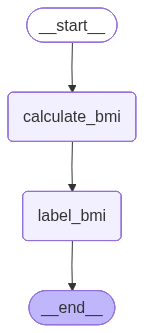

In [7]:
bmi_graph

In [ ]:
bmi_graph.invoke({"weight": 70, "height": 1.75})

Step 1 - BMI calculated: 22.86
Step 2 - Category assigned: Normal


{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal'}

## Example 2: Creating a Blog writer (with LLM)

In [8]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END, START
from typing import TypedDict

In [14]:
load_dotenv()

llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model_name="llama-3.3-70b-versatile"
)


In [15]:
# Create a State
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [16]:
# create outline function
def create_outline(state: BlogState) -> BlogState:
    title = state["title"]
    print(f"Step 1 - Creating outline for: {title}")

    response = llm.invoke([
        HumanMessage(content=f"Create a short blog outline with 3 points for the topic: {title}. Just give the outline points, nothing else.")
    ])

    outline = response.content
    print(f"Outline created: {outline}")
    return {"outline": outline}

In [17]:
# create a blog content function
def create_blog(state: BlogState) -> BlogState:
    title = state["title"]
    outline = state["outline"]
    print(f"Step 2 - Creating blog content for: {title} with outline: {outline}")

    response = llm.invoke([
        HumanMessage(content=f"Write a short blog post of 150 words for title '{title}' using this outline:\n{outline}")
    ])
    
    content = response.content
    print(f"Blog written:\n{content}")
    return {"content": content}

In [13]:
# Build a graph

blog_graph = StateGraph(BlogState)

# add nodes
blog_graph.add_node("create_outline", create_outline)
blog_graph.add_node("create_blog", create_blog)

# add edges
blog_graph.add_edge(START, "create_outline")
blog_graph.add_edge("create_outline", "create_blog")
blog_graph.add_edge("create_blog", END)

blog_graph = blog_graph.compile()

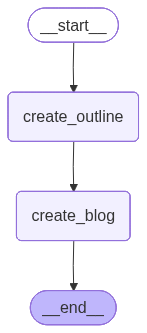

In [18]:
blog_graph

In [9]:
result = blog_graph.invoke({"title": "The Benefits of AI in Healthcare"})

Step 1 - Creating outline for: The Benefits of AI in Healthcare
Outline created: I. Improved Diagnostic Accuracy
II. Enhanced Patient Care and Personalization
III. Streamlined Clinical Workflows and Administrative Tasks
Step 2 - Creating blog content for: The Benefits of AI in Healthcare with outline: I. Improved Diagnostic Accuracy
II. Enhanced Patient Care and Personalization
III. Streamlined Clinical Workflows and Administrative Tasks
Blog written:
The Benefits of AI in Healthcare

The integration of Artificial Intelligence (AI) in healthcare has revolutionized the industry, offering numerous benefits. Firstly, AI improves diagnostic accuracy by analyzing large amounts of medical data, enabling healthcare professionals to make more informed decisions. Secondly, AI enhances patient care and personalization by tailoring treatment plans to individual needs, leading to better health outcomes. Lastly, AI streamlines clinical workflows and administrative tasks, reducing manual errors and 

In [14]:
# print content
print("\nFinal Blog Content:")
print(result["content"])


Final Blog Content:
The Benefits of AI in Healthcare

The integration of Artificial Intelligence (AI) in healthcare has revolutionized the industry, offering numerous benefits. Firstly, AI improves diagnostic accuracy by analyzing large amounts of medical data, enabling healthcare professionals to make more informed decisions. Secondly, AI enhances patient care and personalization by tailoring treatment plans to individual needs, leading to better health outcomes. Lastly, AI streamlines clinical workflows and administrative tasks, reducing manual errors and freeing up staff to focus on high-value tasks. By automating routine tasks, AI enables healthcare providers to allocate more time to patient care, resulting in increased efficiency and productivity. Overall, the adoption of AI in healthcare has the potential to transform the industry, leading to improved patient outcomes, enhanced care, and reduced costs. As AI technology continues to evolve, its benefits will only continue to grow